In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 1. Load Dataset

In [8]:
# Load the movies dataset
df = pd.read_csv("/content/movies.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [9]:
df.shape

(7668, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [11]:
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


In [12]:
df.isnull().sum()

,0
name,0
rating,77
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


In [13]:
df.duplicated().sum()

np.int64(0)

## 2. Data Cleaning

In [14]:
# Drop duplicate rows (if any)
df = df.drop_duplicates()

# Drop rows where 'gross' (our target) is missing — can't train without it
df = df.dropna(subset=['gross'])

# Fill missing budget with median (better than mean for skewed data)
df['budget'] = df['budget'].fillna(df['budget'].median())

# Fill missing runtime with median
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

# Drop rows with missing score or votes (very few missing)
df = df.dropna(subset=['score', 'votes'])

print("Shape after cleaning:", df.shape)
df.isnull().sum()

Shape after cleaning: (7479, 15)


,0
name,0
rating,54
genre,0
year,0
released,0
score,0
votes,0
director,0
writer,3
star,0


## 3. Exploratory Data Analysis (EDA)

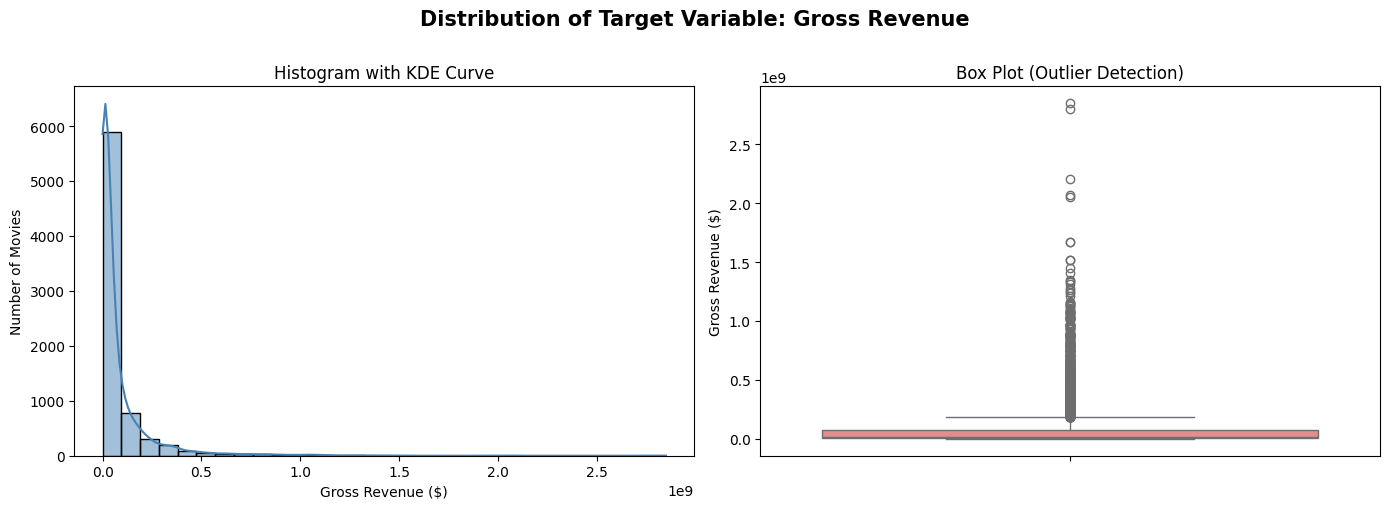

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Target Variable: Gross Revenue', fontsize=15, fontweight='bold', y=1.01)

# Histogram
sns.histplot(df['gross'], kde=True, color='steelblue', ax=axes[0], bins=30)
axes[0].set_title('Histogram with KDE Curve')
axes[0].set_xlabel('Gross Revenue ($)')
axes[0].set_ylabel('Number of Movies')

# Boxplot
sns.boxplot(y=df['gross'], color='lightcoral', ax=axes[1])
axes[1].set_title('Box Plot (Outlier Detection)')
axes[1].set_ylabel('Gross Revenue ($)')

plt.tight_layout()
plt.show()

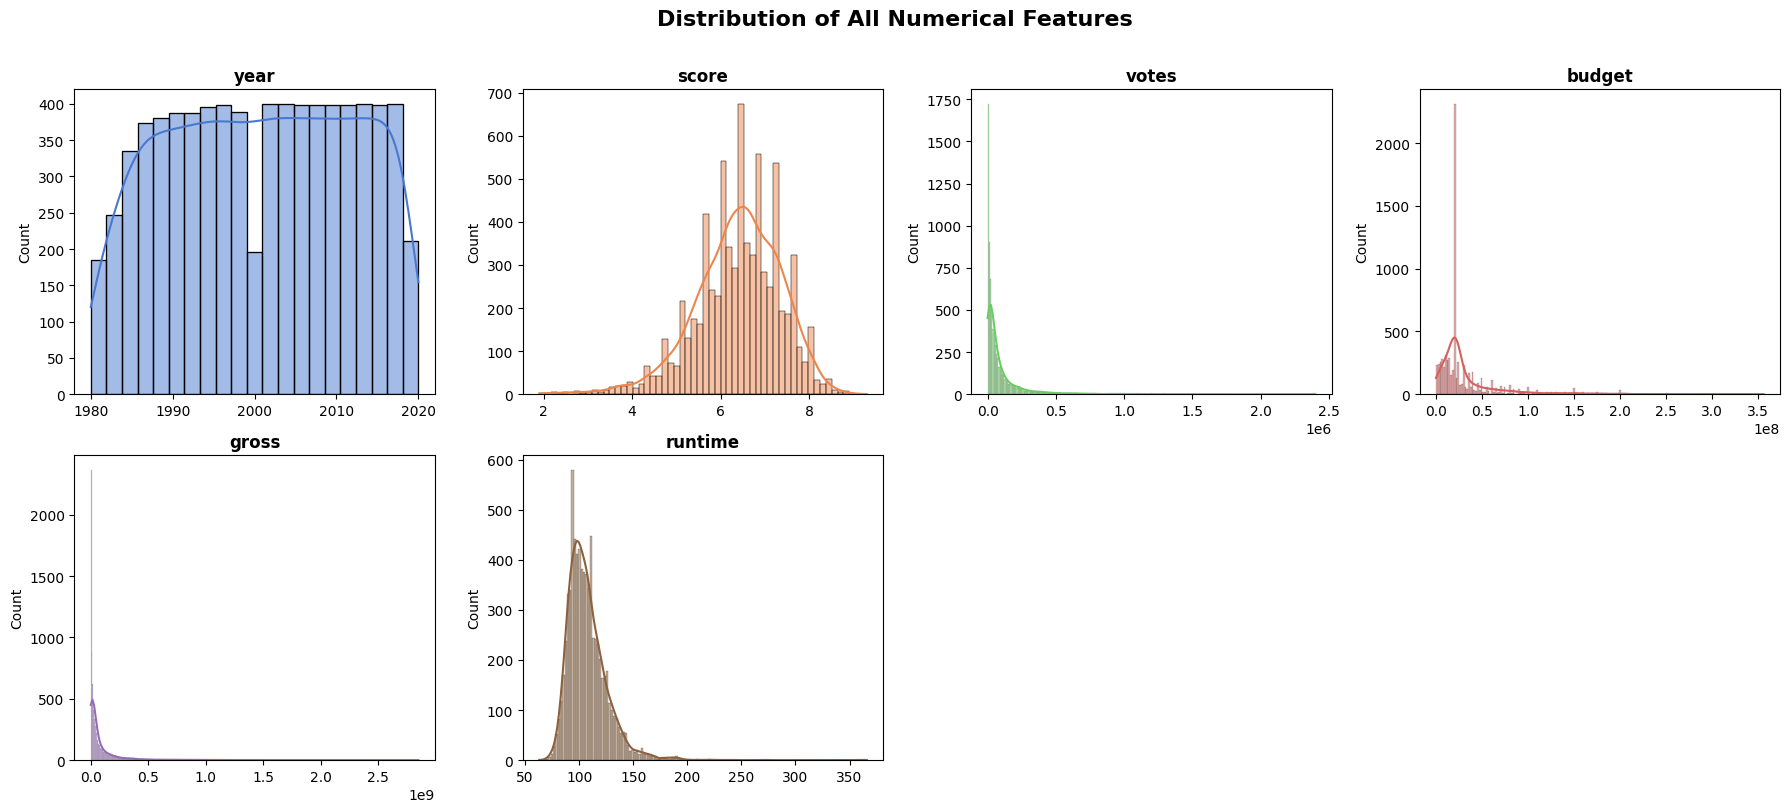

In [16]:
# Histplots for all numeric columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Distribution of All Numerical Features', fontsize=16, fontweight='bold', y=1.01)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4492/2357188815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')


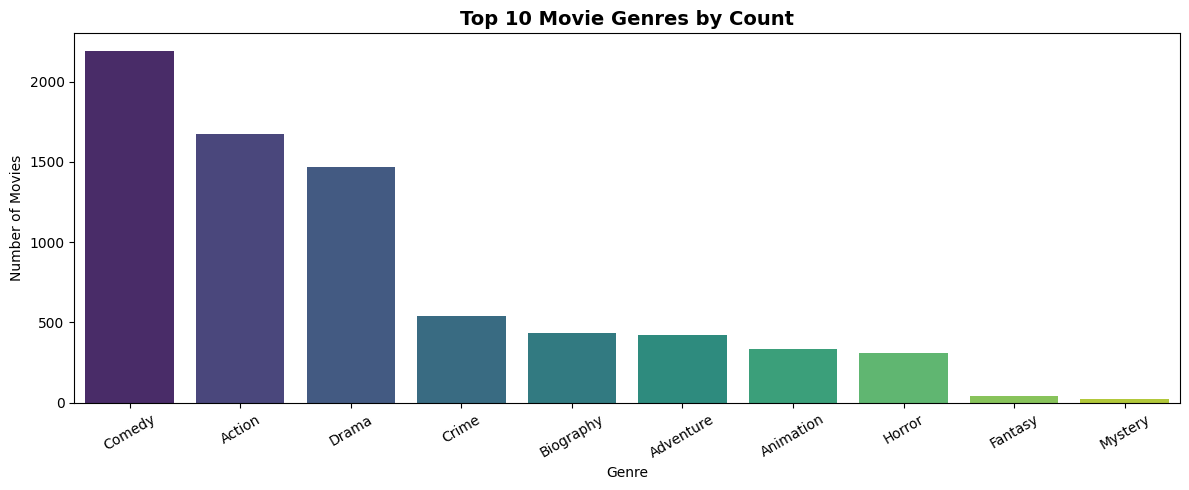

In [17]:
# Count of movies per genre
top_genres = df['genre'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title('Top 10 Movie Genres by Count', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4492/793402542.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_gross.index, y=genre_gross.values, palette='magma')


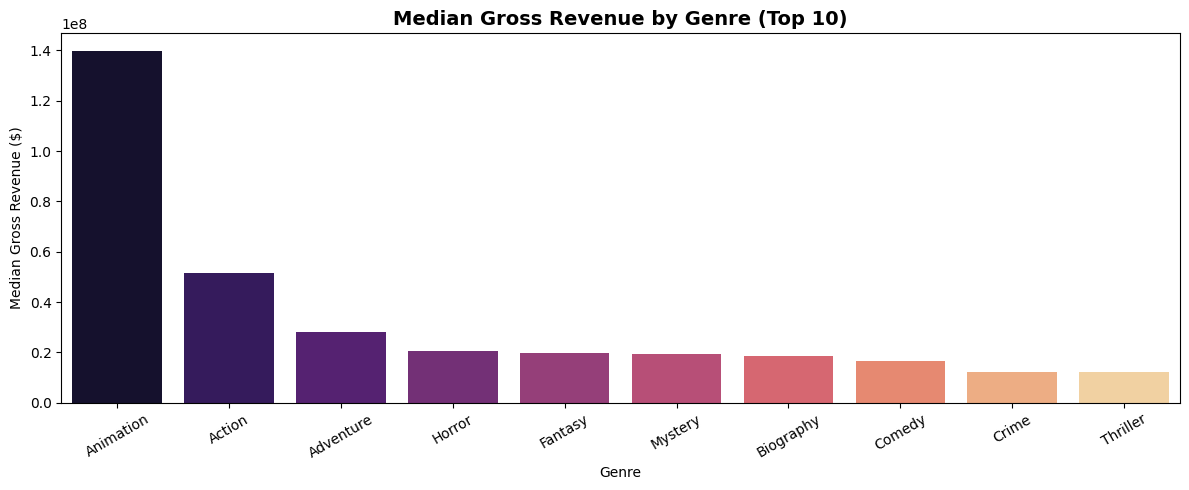

In [18]:
# Average gross revenue per genre
genre_gross = df.groupby('genre')['gross'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_gross.index, y=genre_gross.values, palette='magma')
plt.title('Median Gross Revenue by Genre (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Median Gross Revenue ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4492/1460589277.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_ratings, x='rating', y='gross', palette='Set2', ax=axes[1], order=top_ratings)


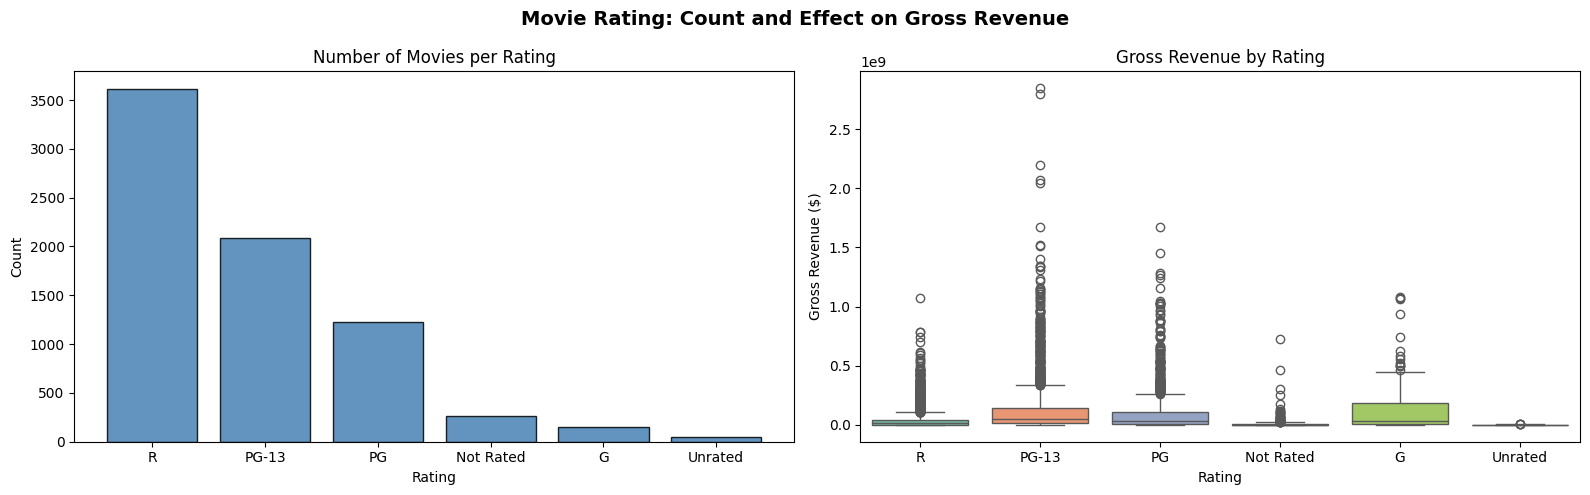

In [19]:
# Rating distribution and their effect on gross
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Movie Rating: Count and Effect on Gross Revenue', fontsize=14, fontweight='bold')

# Count per rating
rating_counts = df['rating'].value_counts().head(6)
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Number of Movies per Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Gross by rating (top 6 ratings only for clarity)
top_ratings = rating_counts.index.tolist()
df_top_ratings = df[df['rating'].isin(top_ratings)]
sns.boxplot(data=df_top_ratings, x='rating', y='gross', palette='Set2', ax=axes[1], order=top_ratings)
axes[1].set_title('Gross Revenue by Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Gross Revenue ($)')

plt.tight_layout()
plt.show()

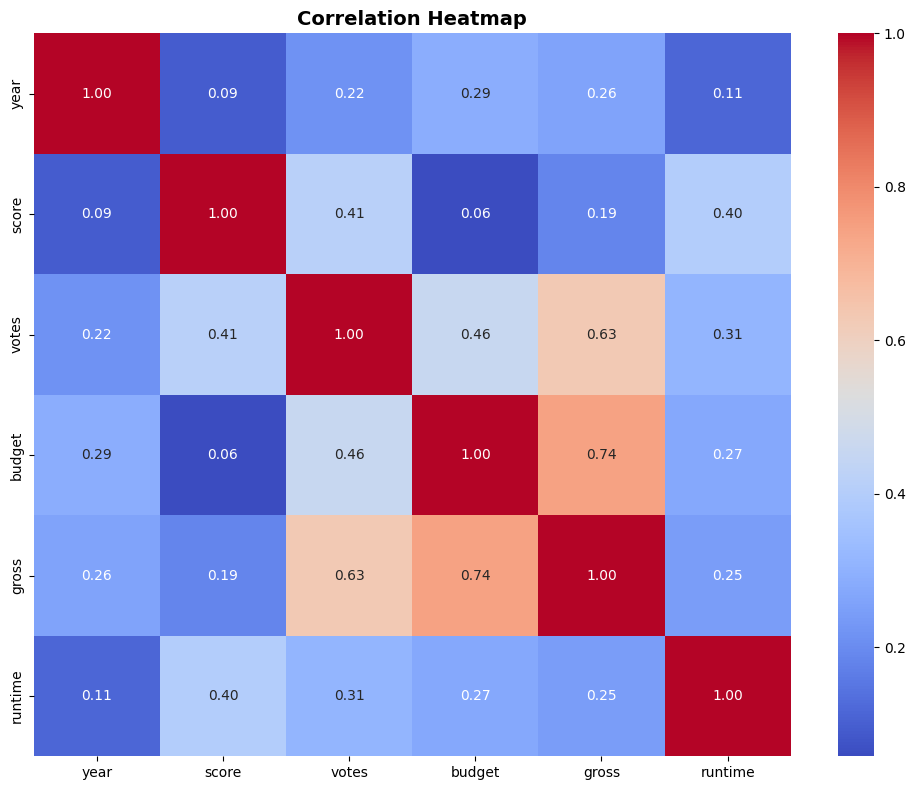

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [21]:
# Profit = Gross - Budget (how much the movie earned above its cost)
df['profit'] = df['gross'] - df['budget']

# ROI = Return on Investment (higher = more efficient movie)
df['ROI'] = df['gross'] / (df['budget'] + 1)  # +1 to avoid division by zero
df['ROI'] = df['ROI'].round(2)

# Encode 'rating' into a simple popularity score (R=1, PG-13=2, PG=3, G=4, others=0)
rating_map = {'G': 4, 'PG': 3, 'PG-13': 2, 'R': 1}
df['rating_encoded'] = df['rating'].map(rating_map).fillna(0)

# Is the movie from USA? (1 = Yes, 0 = No)
df['is_usa'] = (df['country'] == 'United States').astype(int)

print("New features added: profit, ROI, rating_encoded, is_usa")
df[['name', 'budget', 'gross', 'profit', 'ROI', 'rating_encoded', 'is_usa']].head()

New features added: profit, ROI, rating_encoded, is_usa


,name,budget,gross,profit,ROI,rating_encoded,is_usa
0,The Shining,19000000.0,46998772.0,27998772.0,2.47,1.0,0
1,The Blue Lagoon,4500000.0,58853106.0,54353106.0,13.08,1.0,1
2,Star Wars: Episode V - The Empire Strikes Back,18000000.0,538375067.0,520375067.0,29.91,3.0,1
3,Airplane!,3500000.0,83453539.0,79953539.0,23.84,3.0,1
4,Caddyshack,6000000.0,39846344.0,33846344.0,6.64,1.0,1


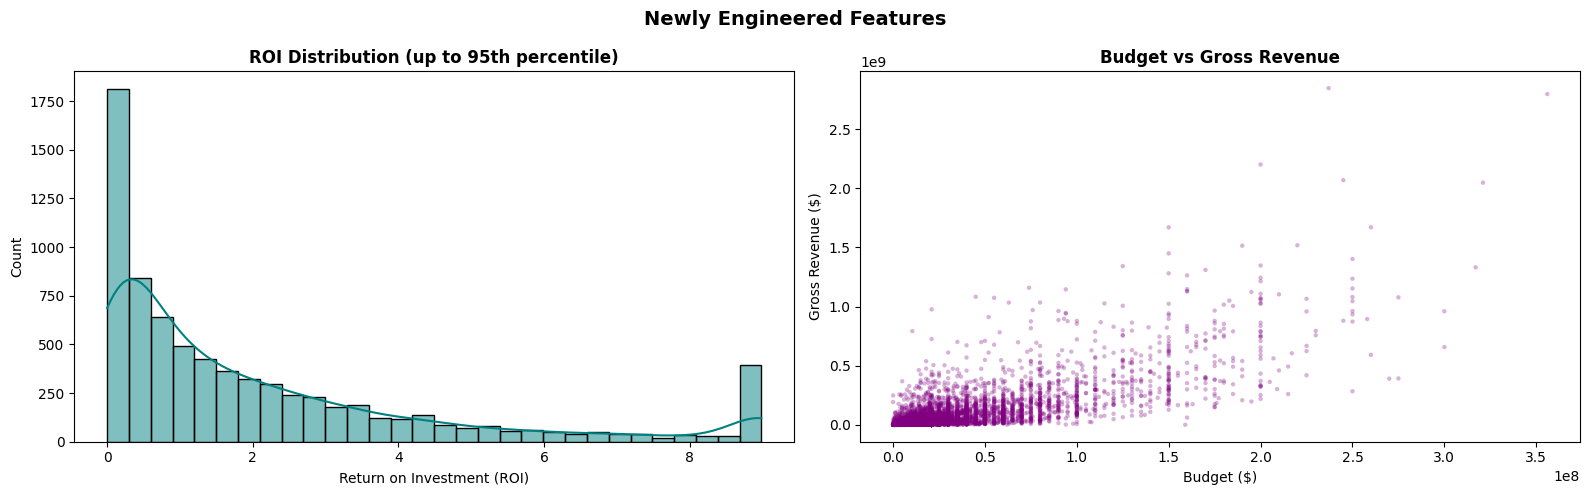

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Newly Engineered Features', fontsize=14, fontweight='bold')

# ROI distribution (clip extreme values for cleaner plot)
roi_clipped = df['ROI'].clip(upper=df['ROI'].quantile(0.95))
sns.histplot(roi_clipped, kde=True, color='teal', ax=axes[0], bins=30)
axes[0].set_title('ROI Distribution (up to 95th percentile)', fontweight='bold')
axes[0].set_xlabel('Return on Investment (ROI)')

# Gross vs budget scatter
axes[1].scatter(df['budget'], df['gross'], alpha=0.3, color='purple', edgecolors='none', s=10)
axes[1].set_title('Budget vs Gross Revenue', fontweight='bold')
axes[1].set_xlabel('Budget ($)')
axes[1].set_ylabel('Gross Revenue ($)')

plt.tight_layout()
plt.show()

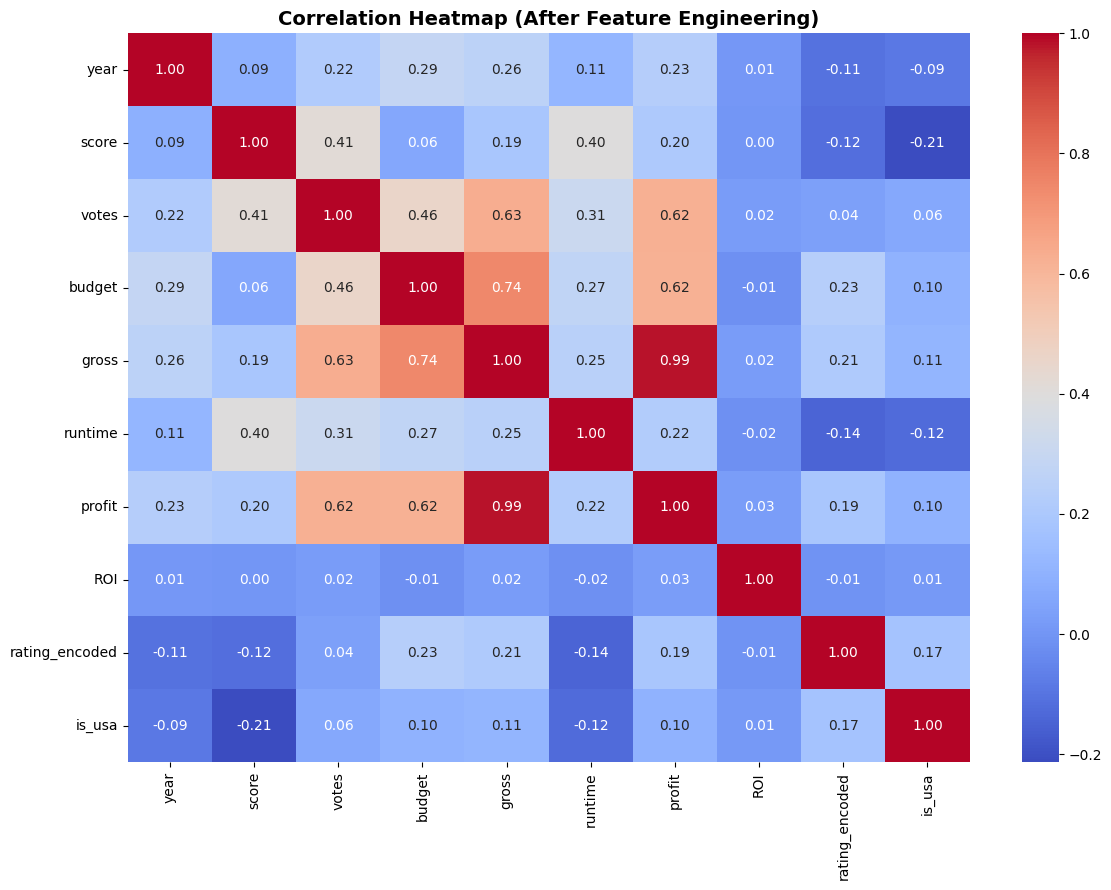


Correlations with Gross Revenue (sorted):
profit            0.985341
budget            0.744926
votes             0.630757
year              0.257486
runtime           0.245221
rating_encoded    0.208976
score             0.186258
is_usa            0.110141
ROI               0.020638


In [23]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (After Feature Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations with Gross Revenue (sorted):')
target_corr = corr['gross'].drop('gross').sort_values(ascending=False)
print(target_corr.to_string())

## 5. Model Preparation

In [24]:
# Features selected based on correlation and domain knowledge
X = df[['budget', 'score', 'votes', 'runtime', 'year', 'rating_encoded', 'is_usa', 'ROI']]
y = df['gross']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7479, 8)
Target shape: (7479,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5983, 8)
Testing size: (1496, 8)


In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Linear SVM": SVR(kernel='linear', C=100, epsilon=0.1),
    "RBF SVM": SVR(kernel='rbf', C=100, gamma=0.1),
    "Polynomial SVM": SVR(kernel='poly', C=100, degree=2),
    "Sigmoid SVM": SVR(kernel='sigmoid', C=100, gamma='scale')
}

## 6. Model Training and Evaluation

In [28]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, r2])

result_df = pd.DataFrame(results, columns=['Model', 'MSE', 'R2'])
print(result_df.to_string(index=False))

                   Model          MSE        R2
       Linear Regression 1.007219e+16  0.691234
        Ridge Regression 1.007269e+16  0.691219
        Lasso Regression 1.007219e+16  0.691234
Decision Tree Regression 1.091154e+15  0.966550
Random Forest Regression 1.501837e+15  0.953961
     K-Nearest Neighbors 8.505919e+15  0.739249
              Linear SVM 3.596197e+16 -0.102424
                 RBF SVM 3.615763e+16 -0.108422
          Polynomial SVM 3.613906e+16 -0.107853
             Sigmoid SVM 3.614471e+16 -0.108026


## Using Ensemble Learning

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

In [30]:
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ('lr', models['Linear Regression']),
        ('ridge', models['Ridge Regression']),
        ('lasso', models['Lasso Regression']),
        ('dt', models['Decision Tree Regression']),
        ('knn', models['K-Nearest Neighbors'])
    ],
    final_estimator=models['Random Forest Regression']
)
stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('ridge', Ridge(alpha=1)),
                              ('lasso', Lasso(alpha=0.1)),
                              ('dt', DecisionTreeRegressor()),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=RandomForestRegressor(n_estimators=150))

In [31]:
y_pred = stack_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(['Stacking', mse, r2])
print(f"Stacking Model — MSE: {mse:.2f}  |  R2: {r2:.4f}")

Stacking Model — MSE: 1812507337943404.25  |  R2: 0.9444


In [32]:
from sklearn.ensemble import VotingRegressor

vote_model = VotingRegressor(
    estimators=[
        ('lr', models['Linear Regression']),
        ('ridge', models['Ridge Regression']),
        ('lasso', models['Lasso Regression']),
        ('dt', models['Decision Tree Regression']),
        ('knn', models['K-Nearest Neighbors']),
        ('rf', models['Random Forest Regression'])
    ]
)

vote_model.fit(X_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('ridge', Ridge(alpha=1)),
                            ('lasso', Lasso(alpha=0.1)),
                            ('dt', DecisionTreeRegressor()),
                            ('knn', KNeighborsRegressor()),
                            ('rf', RandomForestRegressor(n_estimators=150))])

In [33]:
y_pred = vote_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(['Voting', mse, r2])
print(f"Voting Model — MSE: {mse:.2f}  |  R2: {r2:.4f}")

Voting Model — MSE: 5116744948000781.00  |  R2: 0.8431


In [34]:
results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'R2'])
print(results_df.to_string(index=False))

                   Model          MSE        R2
       Linear Regression 1.007219e+16  0.691234
        Ridge Regression 1.007269e+16  0.691219
        Lasso Regression 1.007219e+16  0.691234
Decision Tree Regression 1.091154e+15  0.966550
Random Forest Regression 1.501837e+15  0.953961
     K-Nearest Neighbors 8.505919e+15  0.739249
              Linear SVM 3.596197e+16 -0.102424
                 RBF SVM 3.615763e+16 -0.108422
          Polynomial SVM 3.613906e+16 -0.107853
             Sigmoid SVM 3.614471e+16 -0.108026
                Stacking 1.812507e+15  0.944437
                  Voting 5.116745e+15  0.843145


/tmp/ipykernel_4492/874311010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')


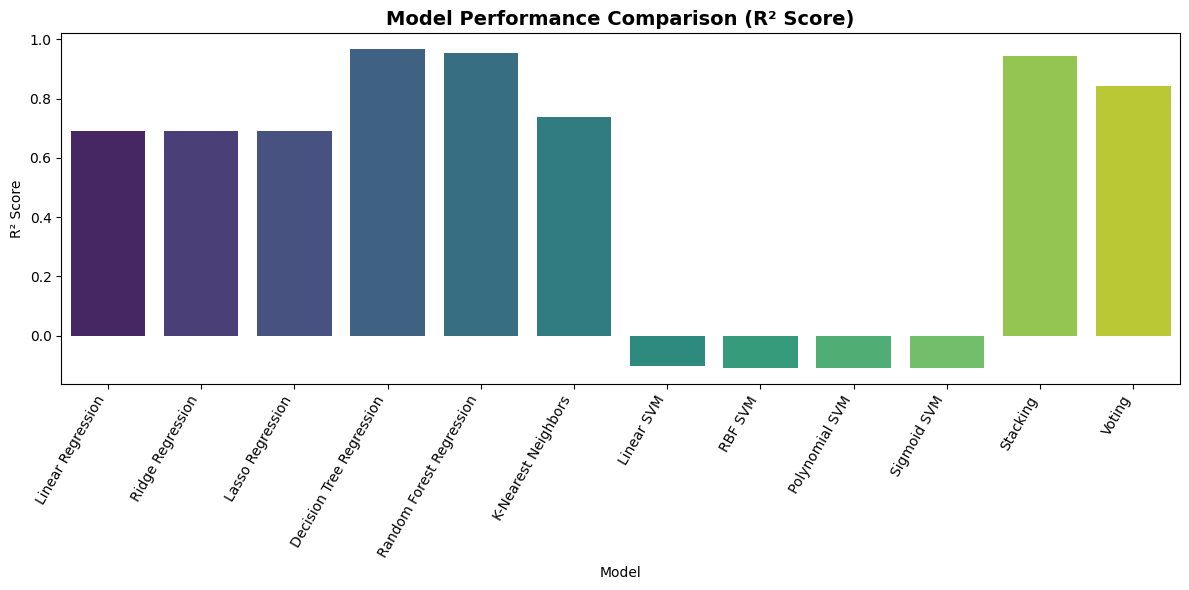

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title('Model Performance Comparison (R² Score)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## 7. Best Model — Random Forest

In [36]:
best_model = RandomForestRegressor(n_estimators=150, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Model: Random Forest Regressor")
print(f"MSE : {mse:.2f}")
print(f"R²  : {r2:.4f}")

Best Model: Random Forest Regressor
MSE : 1521523255618732.75
R²  : 0.9534


## 8. Save the Model

In [38]:
import pickle
pickle.dump(best_model, open("RandomForest_model_movies.pkl", "wb"))
pickle.dump(scaler, open("RandomForest_scaler_movies.pkl", "wb"))
print("Model and scaler saved successfully!")

Model and scaler saved successfully!
